# Non-Negative Matrix Factorization (NMF) vs PCA

## Setup
1. Download the file `face.train.tar.gz`from Moodle, and place it in the same directory as this notebook. It contains the CBCL Face Database from MIT, featuring thousands of small grayscale images of faces.
2.  Ensure you have PyTorch, scikit-learn, and torchvision installed, as we'll use these libraries in this notebook. You can install them using: `pip install torch torchvision scikit-learn`


In [1]:
import glob
import numpy as np
import torch
from PIL import Image

import tarfile

# Extract the .tar.gz file
# Using GDrive:
from google.colab import drive
drive.mount('/content/drive')
dir = '/content/drive/MyDrive/Tutorials/Tutorial_9_coding_materials/face.train.tar.gz'
with tarfile.open(dir, 'r:gz') as tar:
    tar.extractall()

# Prepare the data matrix X
images = []
for file in glob.glob('train/face/*.pgm'):
    images.append(torch.FloatTensor(np.array(Image.open(file))))

# Stack images into a tensor (height, width, num_images)
X = torch.stack(images, dim=-1)
height, width, num_images = X.shape
print(f'Loaded {num_images} images of size {height} x {width}')

img_size = X.shape[:2]
X = X.flatten(0, 1) # Unroll each 2D image into a 1D vector
X /= 255 # Normalize pixel values to range [0, 1]

X.shape

Mounted at /content/drive


/tmp/ipykernel_1587/3812841674.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Loaded 2429 images of size 19 x 19


torch.Size([361, 2429])

## **NMF**

In [2]:
import torch.optim as optim
import torch.nn as nn
import math

K = 49 # Number of Features
num_steps = 5000


# Initialize U and V from uniform distribution U(0, 1), scaled by 1/sqrt(K) to stabilize initial optimization

U = (torch.rand(X.shape[0], K)  / math.sqrt(K)).requires_grad_()
V = (torch.rand(K, X.shape[1])  / math.sqrt(K)).requires_grad_()

optimizer = optim.Adam([U, V], lr=0.005)
criterion = nn.MSELoss()

loss_curve = []
for i in range(num_steps):
    optimizer.zero_grad()
    # Reconstruction of X
    X_hat = U @ V
    loss = criterion(X_hat, X)

    loss.backward()
    optimizer.step()

    # Non-negativity constraints (i.e. Projection onto the set of valid solutions)
    with torch.no_grad():
      U.data.clamp_(min=0)
      V.data.clamp_(min=0)

    # Record loss
    loss_val = loss.item()
    loss_curve.append(loss_val)

    if (i + 1) % 1000 == 0 or i == 0:
        print(f'Step {i+1} | Loss: {loss_val:.05f}')

Step 1 | Loss: 0.11330
Step 1000 | Loss: 0.00252
Step 2000 | Loss: 0.00218
Step 3000 | Loss: 0.00205
Step 4000 | Loss: 0.00200
Step 5000 | Loss: 0.00198


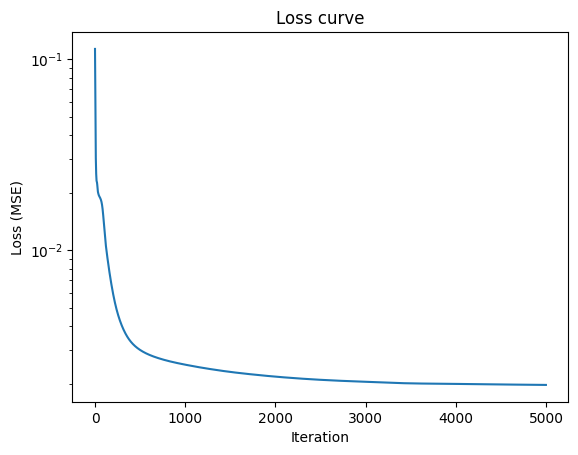

In [3]:
# Loss curve plot
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(loss_curve)
plt.title('Loss curve')
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.yscale('log')

Text(0.5, 1.0, 'NMF features')

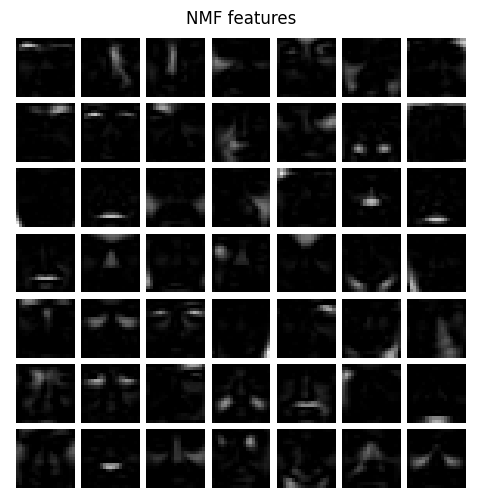

In [4]:
import torchvision
# Each of the 49 columns in U is a basis feature vector of size 361 (19x19 pixels).

# Reshape the basis vectors in U into images of size 19x19
features = U.data.t().view(-1, *img_size).clone()
# Normalize each feature image to [0, 1] for clear visualization
features = (features - features.min()) / (features.max() - features.min()) # Normalize in [0, 1]

# Visualize the basis features in a grid
img = torchvision.utils.make_grid(features.unsqueeze(1), nrow=int(math.sqrt(K)), pad_value=1)
plt.figure(figsize=(6, 6))
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')
plt.title('NMF features')

(np.float64(-0.5), np.float64(6.5), np.float64(6.5), np.float64(-0.5))

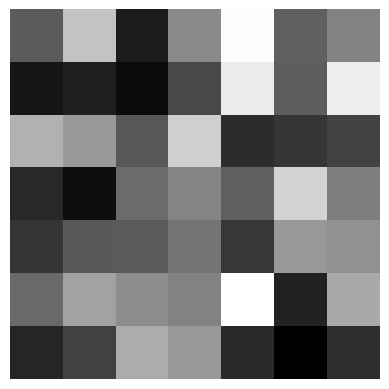

In [5]:
image_idx = 0  # Select the index of the image to visualize feature assignments

# Extract the vector from the assignment matrix V corresponding to the feature assignments for mage_idx
feature_assignment = V.T.data[image_idx].clone()
# Normalize all features globally to [0, 1] for clear visualization
feature_assignment = (feature_assignment - feature_assignment.min()) / (feature_assignment.max() - feature_assignment.min())

plt.imshow(feature_assignment.view(-1, int(math.sqrt(K))).unsqueeze(-1).expand(-1, -1, 3))
plt.axis('off')

# PCA

In [6]:
from sklearn.decomposition import PCA

K = 49

X_np = X.numpy() # Convert tensor to NumPy for sklearn

# Apply PCA to the matrix X (Hint: Use the predefined PCA function)

X_PCA = X_np.T # Transpose X to shape (N, K) for PCA
pca = PCA(n_components=K)
X_reduced = pca.fit_transform(X_PCA)  # Reduced Matrix from PCA

X_reconstructed_PCA = pca.inverse_transform(X_reduced) # Reconstructed Matrix from PCA - Tran

# Transpose back to original shape
X_reconstructed = X_reconstructed_PCA.T

# Reconstruction Loss (MSE)
reconstruction_loss = ((X_np - X_reconstructed)**2).mean()

print(f'Reconstruction Loss: {reconstruction_loss:.5f}')

Reconstruction Loss: 0.00169


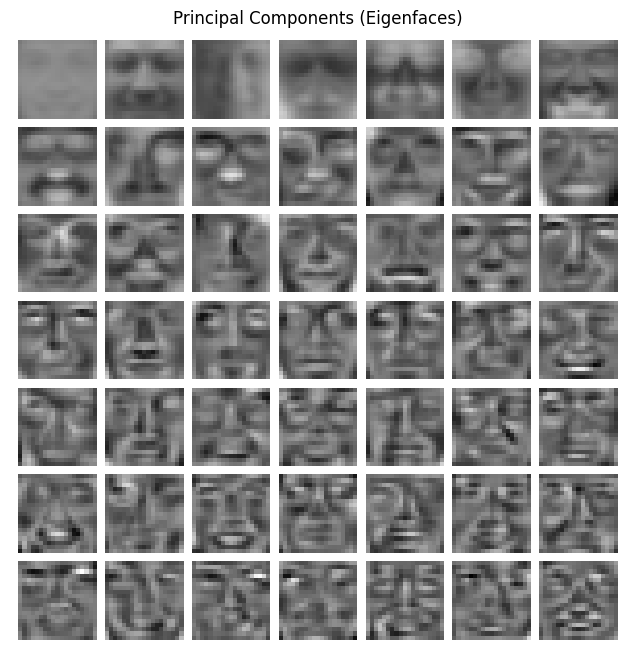

In [7]:
# Visualization of principal components as Eigenfaces
principal_components = torch.from_numpy(pca.components_)
features = principal_components.view(-1, *img_size).clone()
features = (features - features.min()) / (features.max() - features.min())  # Normalize [0, 1]

img = torchvision.utils.make_grid(features.unsqueeze(1), nrow=int(math.sqrt(K)), pad_value=1)
plt.figure(figsize=(8, 8))
plt.imshow(img.permute(1, 2, 0))
plt.axis('off')
plt.title('Principal Components (Eigenfaces)')
plt.show()

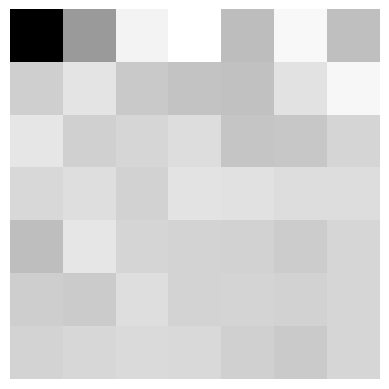

In [8]:
# Select the image index you want to visualize
image_idx = 4

# PCA component assignments (analogous to NMF feature assignments)
feature_assignment = torch.from_numpy(X_reduced[image_idx,:])

# Normalize assignments to [0, 1] for visualization
feature_assignment = (feature_assignment - feature_assignment.min())/ (feature_assignment.max() - feature_assignment.min())
feature_img_size = int(math.sqrt(K))
feature_assignment_img = feature_assignment.view(feature_img_size, feature_img_size)
feature_assignment_rgb = feature_assignment_img.unsqueeze(-1).expand(-1, -1, 3)

# Plot
plt.imshow(feature_assignment_rgb)
plt.axis('off')
plt.show()

NMF decomposes images into additive combinations of basis components. Thus, NMF produces factors that correspond to different parts of the face such as the eyes and the nose, and different edges or textures. Hence, it results in an interpretable parts-based representation which captures meaningful structures of the database.

In contrast, Principal Component Analysis generates global representations, allowing both positive and negative contributions. PCA seeks directions of maximum variance in the data, generating orthogonal components called eigenfaces. Each eigenface captures abstract, global variations such as the  overall facial shape or illumination patterns, across the entire face. However, these components do not necessarily directly correspond to recognizable facial features or parts.
